## 1. Introduction
This project analyses Tesla stock prices using time series methods including ARIMA modelling, stationarity testing, and forecasting.

## 2. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import itertools

from sklearn.metrics import mean_squared_error, mean_absolute_error
import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot
from statsmodels.tsa.seasonal import STL, seasonal_decompose
from pandas.plotting import lag_plot


## 3. Data Collection and Cleaning
We download Tesla stock prices and align to business days.

In [2]:
data = yf.download("TSLA", start="2015-01-01", end="2026-01-01")

close = data["Close"].copy()
close.index = pd.to_datetime(close.index)

close_b = close.asfreq("B").ffill()

print(close_b.head())


[*********************100%***********************]  1 of 1 completed


Ticker           TSLA
Date                 
2015-01-02  14.620667
2015-01-05  14.006000
2015-01-06  14.085333
2015-01-07  14.063333
2015-01-08  14.041333


## 4. Line Plot
Shows trend and volatility.

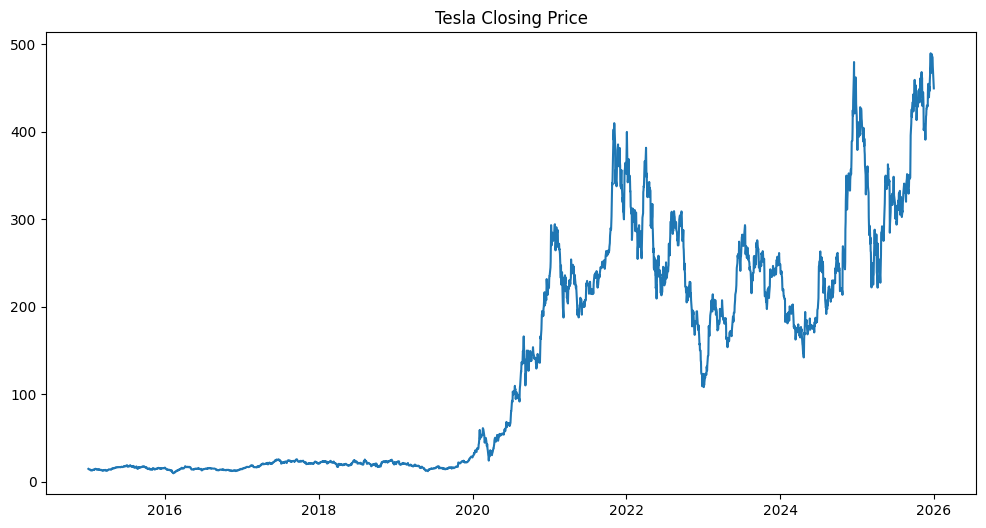

In [3]:
plt.figure(figsize=(12,6))
plt.plot(close_b)
plt.title("Tesla Closing Price")
plt.show()

## 5. Rolling Mean
Shows changing mean over time.

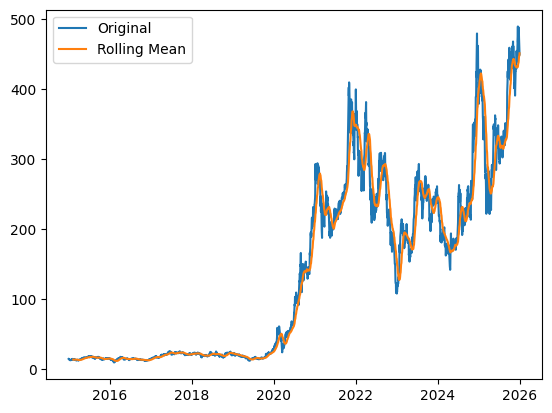

In [4]:
rolling_mean = close_b.rolling(30).mean()
plt.plot(close_b, label="Original")
plt.plot(rolling_mean, label="Rolling Mean")
plt.legend()
plt.show()

## 6. Histogram
Shows distribution of prices.

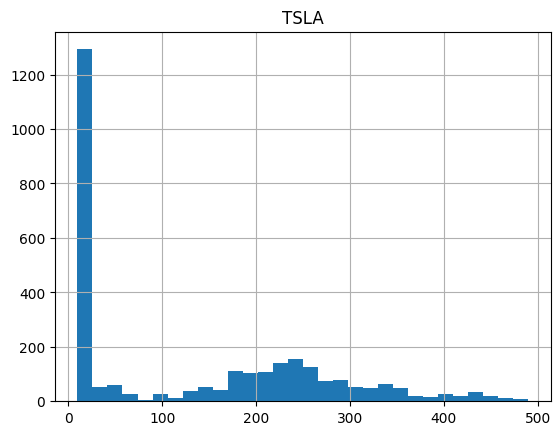

In [5]:
close_b.hist(bins=30)
plt.show()

## 7. Log Returns
Removes trend and stabilises variance.

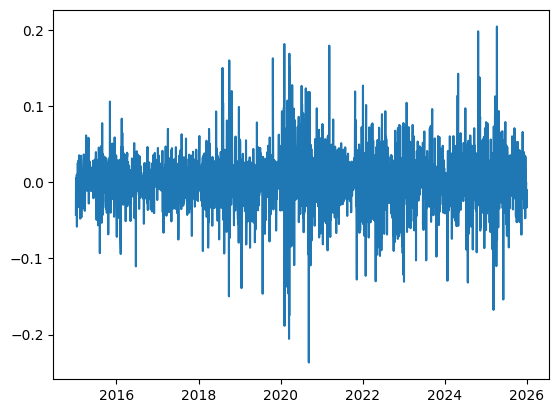

In [6]:
log_close = np.log(close_b)
log_returns = log_close.diff().dropna()
plt.plot(log_returns)
plt.show()

## 8. Boxplot
Shows spread and outliers.

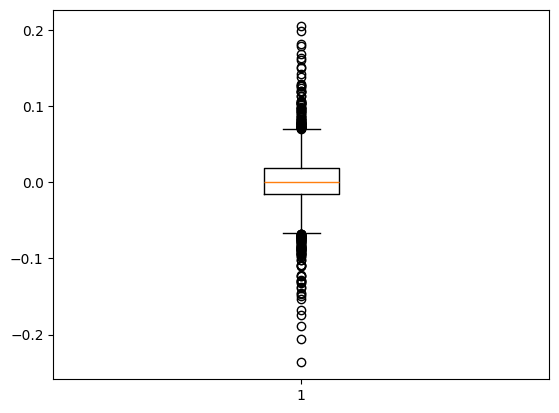

In [7]:
plt.boxplot(log_returns)
plt.show()

## 9. Rolling Volatility
Shows heteroskedasticity.

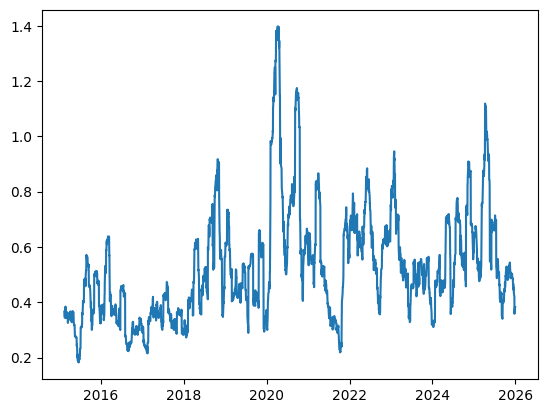

In [8]:
rolling_vol = log_returns.rolling(30).std()*np.sqrt(252)
plt.plot(rolling_vol)
plt.show()

## 10. STL Decomposition
Separates trend, seasonal, residual.

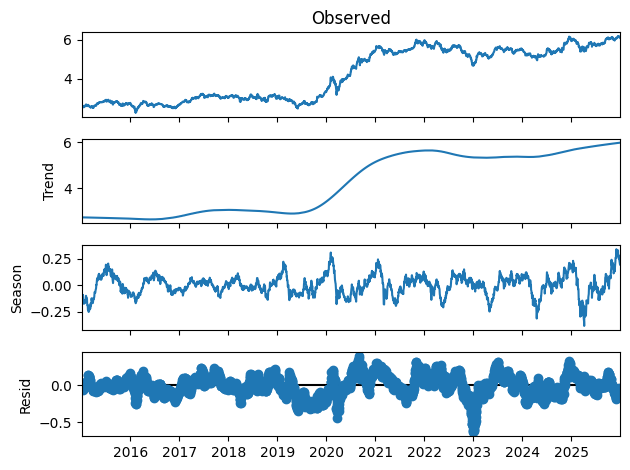

In [9]:
stl = STL(log_close, period=252)
res = stl.fit()
res.plot()
plt.show()

## 11. ADF Test
Tests unit root.

In [10]:
print(adfuller(log_close))
print(adfuller(log_returns))

(np.float64(-0.4869182686728933), np.float64(0.8945441267200149), 0, 2868, {'1%': np.float64(-3.43263213476853), '5%': np.float64(-2.862548291896071), '10%': np.float64(-2.5673067431757923)}, np.float64(-10862.645209927932))
(np.float64(-54.171340656495204), 0.0, 0, 2867, {'1%': np.float64(-3.4326329314838997), '5%': np.float64(-2.862548643765697), '10%': np.float64(-2.5673069305091714)}, np.float64(-10859.826276501697))


## 12. KPSS Test
Confirms stationarity.

In [11]:
print(kpss(log_close))
print(kpss(log_returns))

(np.float64(8.049580629687114), np.float64(0.01), 31, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
(np.float64(0.10172224656255059), np.float64(0.1), 2, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


C:\Users\killi\AppData\Local\Temp\ipykernel_24816\113544853.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  print(kpss(log_close))
C:\Users\killi\AppData\Local\Temp\ipykernel_24816\113544853.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print(kpss(log_returns))


## 13. ACF and PACF
Used for model selection.

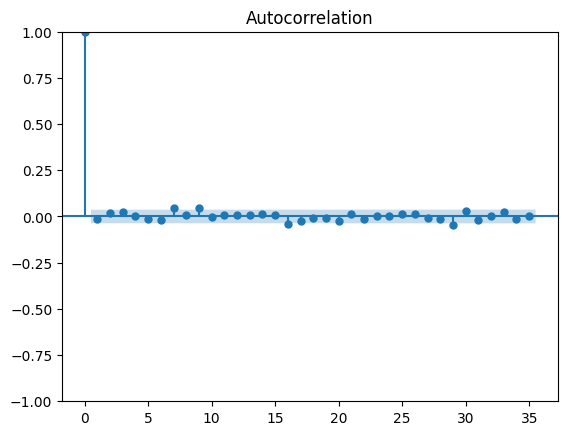

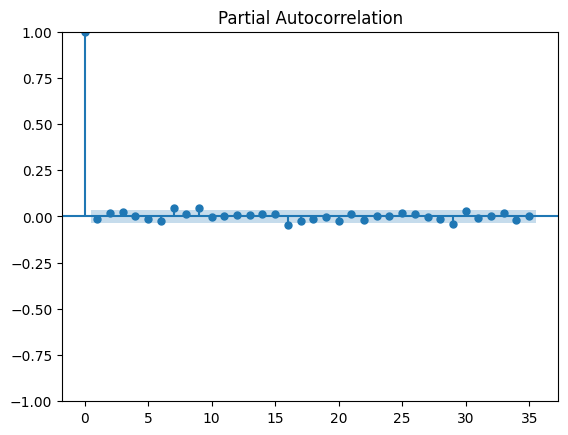

In [12]:
plot_acf(log_returns)
plt.show()

plot_pacf(log_returns)
plt.show()

## 14. Lag Plot
Shows relationship between consecutive values.

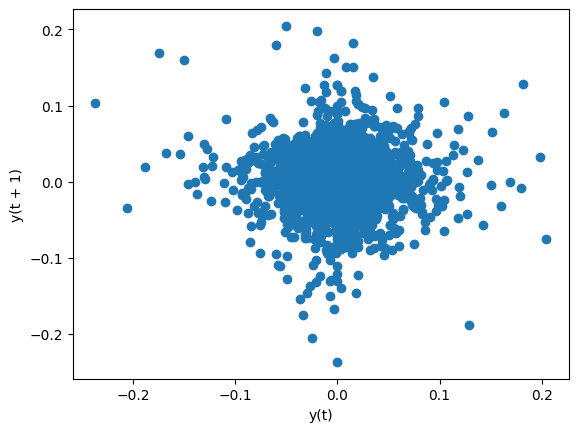

In [13]:
lag_plot(log_returns)
plt.show()

## 15. Train/Test Split

In [14]:
train_size = int(len(close_b)*0.8)
train = close_b[:train_size]
test = close_b[train_size:]

## 16. ARIMA Grid Search

In [15]:
p=q=range(3)
results=[]

for order in [(i,1,j) for i in p for j in q]:
    try:
        fit = ARIMA(train, order=order).fit()
        results.append((order, fit.aic))
    except:
        pass

results_df = pd.DataFrame(results, columns=["order","AIC"]).sort_values("AIC")
print(results_df.head())

c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\killi\anaconda3\envs\ml\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


       order           AIC
8  (2, 1, 2)  14393.153166
3  (1, 1, 0)  14418.840127
1  (0, 1, 1)  14418.860814
0  (0, 1, 0)  14419.652964
4  (1, 1, 1)  14420.794140


## 17. Best Model

In [16]:
best_order = results_df.iloc[0]["order"]
fit = ARIMA(train, order=best_order).fit()
print(best_order)

(2, 1, 2)


## 18. Forecast and RMSE

In [17]:
pred = fit.forecast(steps=len(test))
rmse = np.sqrt(mean_squared_error(test, pred))
print(rmse)

115.63419119094074


## 19. Forecast Plot

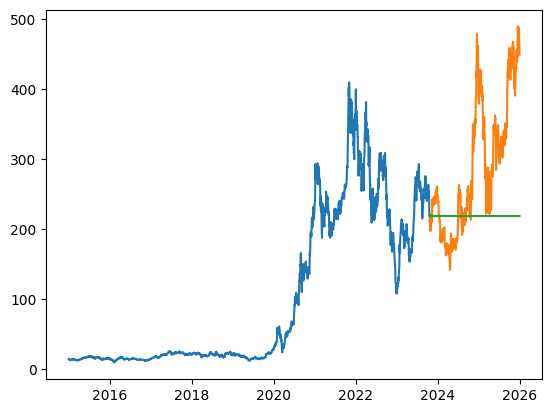

In [18]:
plt.plot(train)
plt.plot(test)
plt.plot(test.index, pred)
plt.show()

## 20. Residual Analysis

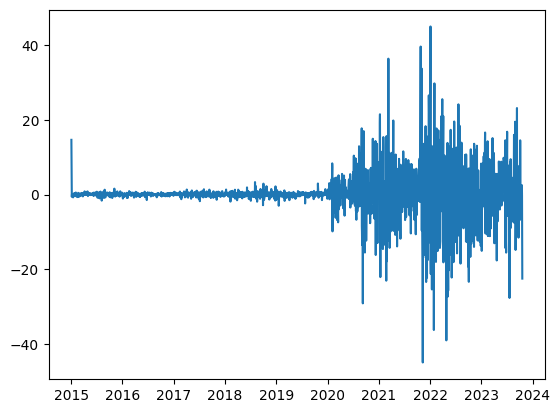

In [19]:
residuals = fit.resid
plt.plot(residuals)
plt.show()

## 21. Q-Q Plot

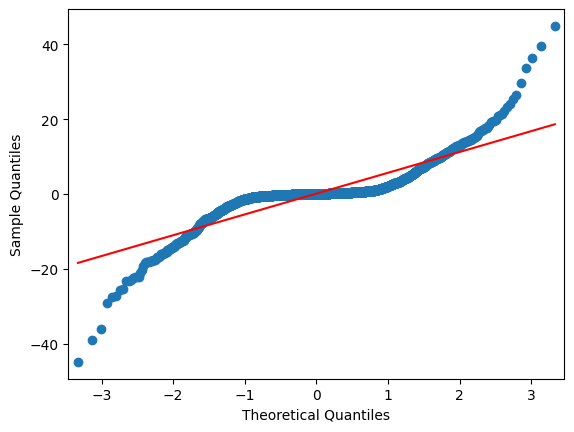

In [20]:
qqplot(residuals, line='s')
plt.show()

## 22. Ljung-Box Test

In [21]:
print(acorr_ljungbox(residuals, lags=[10]))

      lb_stat  lb_pvalue
10  36.499585   0.000069


## 23. Forecast with Confidence Intervals

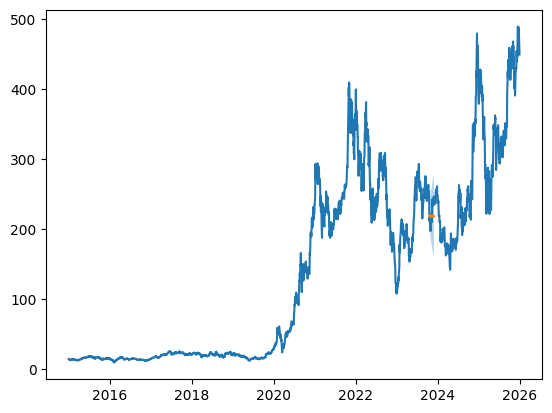

In [22]:
forecast = fit.get_forecast(30)
mean = forecast.predicted_mean
ci = forecast.conf_int()

plt.plot(close_b)
plt.plot(mean)
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], alpha=0.3)
plt.show()